## Notch experiments: do not run, outdated methods 

In [1]:
# Import modules:
from beam_manager import open_beam_library, sublibrary
from bridge_manager import Bridge

import numpy as np
import matplotlib.pyplot as plt

c:\Users\Reinoud van Holk\OneDrive - Delft University of Technology\Bestanden van Jules van der Veen - BEP 2026\Python\U-U Filter\beam_manager.py:78: SyntaxWarning: "\O" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\O"? A raw string is also an option.
  ax.axhline(self.R_0, color='red', linestyle='--', label=f'R_0 = {self.R_0} $\Omega$')


In [2]:
# Initiation: load beam library, select beams for experiment and set parameters.
test_library = open_beam_library('notch8_3.json')
selection = ['A1', 'A2', 'B1', 'B2', 'C1', 'C2', 'D1']
lib = sublibrary(selection, test_library)

R_ref = 100 # Ohm
U_in = 10 # V

f_arr = np.logspace(1, 5, 500)
w_arr = 2*np.pi*f_arr

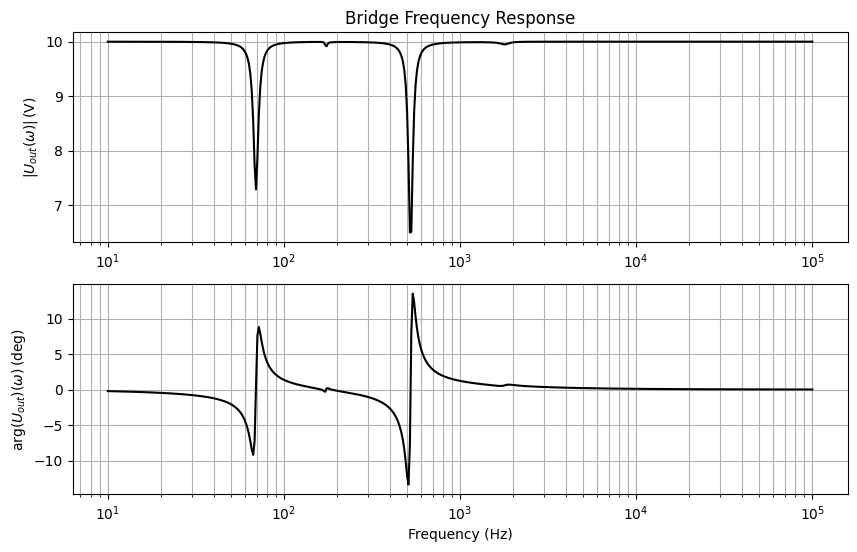

In [3]:
# Experiment 1.1: triangle frequency response:

# Try to build a triangle with A in the floor, B inclined at the left and a C at the right.
topology = [(0, 2), (0, 1), (1, 2), (2, 3), (1, 4), (1, 3), (3, 4)]
struc = Bridge()
struc.construct(lib, topology)

U_arr = np.array([struc.solve_U(w, U_in, R_ref) for w in w_arr]).T
U_out_arr = U_arr[-1,:]
U_mag = np.abs(U_out_arr)
U_phase = np.angle(U_out_arr)

# Plotting:
plt.figure(figsize=(10, 6))

# Plot Magnitude
plt.subplot(2, 1, 1)
plt.semilogx(f_arr, U_mag, color='black')
plt.ylabel(r'$|U_{out}(\omega)|\,(\text{V})$')
plt.grid(True, which="both")
plt.title('Bridge Frequency Response')

# Plot Phase:
plt.subplot(2, 1, 2)
plt.semilogx(f_arr, np.degrees(U_phase), color='black')
plt.ylabel(r'$\text{arg}(U_{out})(\omega)\,(\text{deg})$')
plt.xlabel('Frequency (Hz)')
plt.grid(True, which="both", ls="-")

In [4]:
# Experiment 1.2: recover R values for deformed triangle:

# For the next experiment, we will frequency sweep a deformed bridge and try to recover its R vector.
# We will pretend f_arr contains all 500 sweeping frequencies.

# Let's pretend no deformation in A, but elongation in both B and C:
R_deformed = [50, 55.0, 100.0, 110, 200, 220, 300] # 10 % increase for both B and C resistance.

# The measured response (without noise!) should equal:
U_arr_mes = np.array([struc.solve_U(w, U_in, R_ref, R_vec=R_deformed) for w in w_arr]).T
U_out_mes = U_arr_mes[-1,:]

# Let's see what resistances the solver predicts:
R_pred = struc.predict_R(w_arr, U_in, U_out_mes, R_ref)
print(R_pred)





[ 44.22904137  62.12754064  92.7303468  218.72061884 191.90909379
 113.57116503 285.16721467]
